# Chapter 9 Teaching Code: Vessel Resistance and Propulsion Power Estimation

This notebook demonstrates how AIS trajectory records can be combined with empirical naval architecture formulas to estimate vessel resistance, propulsion power, and fuel consumption. The workflow includes data loading, resistance model construction, AIS-based power calculation, and visualization of the resulting resistance and power time series.


In [1]:
import pandas as pd
import numpy as np
from dataclasses import dataclass

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.offsetbox import AnchoredText

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter


## 1. Load AIS and Environmental Data

The input dataset is assumed to contain vessel position, speed, course, timestamp, and matched metocean variables such as current, wind, and wave conditions. These variables are later used to calculate calm-water resistance, wind resistance, and wave-induced added resistance.


In [2]:
# Load the AIS trajectory dataset with matched environmental variables.
df = pd.read_csv('ais_with_era5_cmems_final.csv')


The following cell displays the loaded dataframe so that the column names and data structure can be checked before the resistance calculation.


In [3]:
df

,postime,ID,lon,lat,distance,sog,cog,draught,wind_u,wind_v,Hs,Tp,heading_wave,current_u,current_v
0,2022-11-04 19:47:58,0_217,115.746682,-32.044075,0.18,3.5,205.0,12.5,-3.053263,3.786142,2.077625,9.180321,214.150662,-0.030015,0.057506
1,2022-11-04 19:56:58,0_217,115.733335,-32.054580,0.93,8.6,263.0,12.5,-3.171411,3.828112,2.077625,9.180321,214.150662,-0.031432,0.068714
2,2022-11-04 20:06:58,0_217,115.700893,-32.048315,1.70,13.4,337.0,12.5,-3.415959,4.073048,2.077625,9.180321,214.150662,-0.034615,0.080026
3,2022-11-04 20:17:00,0_217,115.694013,-32.009243,2.36,14.2,357.0,12.5,-3.505039,4.083810,2.077625,9.180321,214.150662,-0.036211,0.053869
4,2022-11-04 20:26:15,0_217,115.691625,-31.976163,1.98,11.6,323.0,12.5,-3.542115,4.030517,2.077625,9.180321,214.150662,-0.028564,0.046493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,2022-11-10 04:18:20,0_217,103.777260,1.248985,0.54,8.1,326.0,12.5,1.645069,-1.096239,0.190489,2.886626,341.617083,-0.469925,-0.103684
1239,2022-11-10 04:22:40,0_217,103.774428,1.256068,0.46,5.2,359.0,12.5,1.582091,-1.045444,0.189483,2.890906,341.507748,-0.461914,-0.079150
1240,2022-11-10 04:24:50,0_217,103.774675,1.259485,0.20,5.8,16.0,12.5,1.546110,-1.024214,0.189156,2.896395,341.559440,-0.461914,-0.079150
1241,2022-11-10 04:29:51,0_217,103.778295,1.265478,0.42,3.9,37.0,12.5,1.463176,-0.977672,0.188805,2.912926,341.797249,-0.461914,-0.079150


## 2. Define Ship Parameters and Resistance Models

This section defines the ship geometry, propulsive efficiency, and empirical calculation functions. The calm-water component is estimated using Holtrop-type resistance terms, while the environmental added resistance components are calculated from wind and wave information. The final output is the shaft power required to overcome the total resistance.


In [4]:
# Define ship parameters, resistance components, and propulsion power calculation functions.
@dataclass(frozen=True)
class ShipParam:
    Lwl: float = 235.0
    Lpp: float = 230.4
    B: float = 41.5
    Cp: float = 0.8467
    Cm: float = 0.99
    C_B: float = 0.8219
    C_wp: float = 0.91
    L_CB: float = -0.75
    T: float = 13.1
    Tf: float = 13.1
    Ss: float = 13682.0
    ks: float = 150e-6
    Vol: float = 105000.0
    g: float = 9.81
    A_bt: float = 30.8
    hb: float = 4.0
    C_stern: float = 10.0
    k2: float = 1.5
    transom_a: float = 42.6
    i_E: float = 5.0

    Sapp: float = 50.0
    I: float = 14762925.0
    Awl: float = 9561.6
    kyy: float = 60.2966
    A_transverse: float = 41.0 * 5.0

    SFOC: float = 200.0


@dataclass(frozen=True)
class Efficiency:
    eta_R: float = 1.00
    eta_O: float = 0.60
    eta_S: float = 0.99
    eta_H: float = 1.10

    @property
    def total(self):
        return self.eta_R * self.eta_O * self.eta_S * self.eta_H


def heading_unit_vector(heading_deg):
    heading_rad = np.deg2rad(heading_deg)
    return np.array([np.sin(heading_rad), np.cos(heading_rad)])


def relative_angle_180(angle_1, angle_2):
    return abs(180.0 - abs(abs(angle_1 - angle_2) - 180.0))


def vector_to_heading_deg(u, v):
    heading = np.rad2deg(np.arctan2(u, v))
    return np.mod(heading, 360.0)


def speed_over_ground_to_water(v_sog, heading_ship, current_u=0.0, current_v=0.0):
    ship_dir = heading_unit_vector(heading_ship)
    current_vec = np.array([current_u, current_v])
    current_along_track = np.dot(current_vec, ship_dir)
    return max(v_sog - current_along_track, 0.0)


class HoltropParam:
    def __init__(self, ship: ShipParam):
        self.c13 = 1.0 + 0.003 * ship.C_stern

        ratio_T_L = ship.T / ship.Lwl
        if ratio_T_L > 0.05:
            self.c12 = ratio_T_L ** 0.2228446
        elif ratio_T_L < 0.02:
            self.c12 = 0.479948
        else:
            self.c12 = 48.20 * (ratio_T_L - 0.02) ** 2.078 + 0.479948

        self.L_R = ship.Lwl * (
            1.0 - ship.Cp + 0.06 * ship.Cp * ship.L_CB / (4.0 * ship.Cp - 1.0)
        )

        self.k1 = self.c13 * (
            0.93
            + self.c12
            * (ship.B / self.L_R) ** 0.92497
            * (0.95 - ship.Cp) ** (-0.521448)
            * (1.0 - ship.Cp + 0.0225 * ship.L_CB) ** 0.6906
        )

        self.ie = 1.0 + 89.0 * np.exp(
            -((ship.Lwl / ship.B) ** 0.80856)
            * ((1.0 - ship.C_wp) ** 0.30484)
            * ((1.0 - ship.Cp - 0.0225 * ship.L_CB) ** 0.6367)
            * ((self.L_R / ship.B) ** 0.34574)
            * ((100.0 * ship.Vol / ship.Lwl**3) ** 0.16302)
        )

        if ship.Cp <= 0.80:
            self.c16 = 8.07981 * ship.Cp - 13.8673 * ship.Cp**2 + 6.984388 * ship.Cp**3
        else:
            self.c16 = 1.73014 - 0.7067 * ship.Cp

        volume_ratio = ship.Lwl**3 / ship.Vol
        if volume_ratio < 512.0:
            self.c15 = -1.69385
        elif volume_ratio > 1727.0:
            self.c15 = 0.0
        else:
            self.c15 = -1.69385 + (ship.Lwl / ship.Vol ** (1.0 / 3.0) - 8.0) / 2.36

        self.m1 = (
            0.0140407 * ship.Lwl / ship.T
            - 1.75254 * ship.Vol ** (1.0 / 3.0) / ship.Lwl
            - 4.79323 * ship.B / ship.Lwl
            - self.c16
        )

        ratio_B_L = ship.B / ship.Lwl
        if ratio_B_L < 0.11:
            self.c7 = 0.229577 * ratio_B_L ** (1.0 / 3.0)
        elif ratio_B_L > 0.25:
            self.c7 = 0.5 - 0.0625 * ship.Lwl / ship.B
        else:
            self.c7 = ratio_B_L

        self.c1 = (
            2223105.0
            * self.c7**3.78613
            * (ship.T / ship.B) ** 1.07961
            * (90.0 - self.ie) ** (-1.37565)
        )

        self.c3 = (
            0.56
            * ship.A_bt**1.5
            / (ship.B * ship.T * (0.31 * np.sqrt(ship.A_bt) + ship.Tf - ship.hb))
        )

        self.c2 = np.exp(-1.89 * np.sqrt(self.c3))
        self.c5 = 1.0 - 0.8 * ship.transom_a / (ship.B * ship.T * ship.Cm)
        self.c4 = min(ship.Tf / ship.Lwl, 0.04)

        if ship.Lwl / ship.B < 12.0:
            self.lamda = 1.446 * ship.Cp - 0.03 * ship.Lwl / ship.B
        else:
            self.lamda = 1.446 * ship.Cp - 0.36

        self.d = -0.9
        self.PB = 0.56 * np.sqrt(ship.A_bt) / (ship.Tf - 1.5 * ship.hb)

        self.C_A = (
            0.006 * (ship.Lwl + 100.0) ** (-0.16)
            - 0.00205
            + 0.003
            * np.sqrt(ship.Lwl / 7.5)
            * ship.C_B**4
            * self.c2
            * (0.04 - self.c4)
        )


def reynolds_number(v, ship=ShipParam(), nu=1.187e-6):
    v = max(float(v), 1e-8)
    return v * ship.Lpp / nu


def frictional_coefficient(v, ship=ShipParam(), nu=1.187e-6):
    Re = reynolds_number(v, ship, nu)
    return 0.075 / (np.log10(Re) - 2.0) ** 2


def froude_number(v, ship=ShipParam()):
    return float(v) / np.sqrt(ship.g * ship.Lpp)


def frictional_resistance(v, ship=ShipParam(), rho_sw=1025.0):
    if v <= 0.0:
        return 0.0
    C_F = frictional_coefficient(v, ship)
    return 0.5 * rho_sw * ship.Ss * v**2 * C_F


def appendage_resistance(v, ship=ShipParam(), rho_sw=1025.0):
    if v <= 0.0:
        return 0.0
    C_F = frictional_coefficient(v, ship)
    return 0.5 * rho_sw * v**2 * ship.Sapp * ship.k2 * C_F


def wave_making_resistance(v, ship=ShipParam(), rho_sw=1025.0):
    if v <= 0.0:
        return 0.0

    h = HoltropParam(ship)
    Fn = max(froude_number(v, ship), 1e-8)
    m2 = h.c15 * ship.Cp**2 * np.exp(-0.1 * Fn ** (-2.0))

    return (
        h.c1
        * h.c2
        * h.c5
        * ship.Vol
        * rho_sw
        * ship.g
        * np.exp(h.m1 * Fn**h.d + m2 * np.cos(h.lamda * Fn ** (-2.0)))
    )


def bulbous_bow_resistance(v, ship=ShipParam(), rho_sw=1025.0):
    if v <= 0.0:
        return 0.0

    h = HoltropParam(ship)

    denominator = (
        ship.g * (ship.Tf - ship.hb - 0.25 * np.sqrt(ship.A_bt))
        + 0.15 * v**2
    )

    if denominator <= 0.0:
        return 0.0

    Fni = v / np.sqrt(denominator)

    return (
        0.11
        * np.exp(-3.0 / h.PB**2)
        * Fni**3
        * ship.A_bt**1.5
        * rho_sw
        * ship.g
        / (1.0 + Fni**2)
    )


def correlation_resistance(v, ship=ShipParam(), rho_sw=1025.0):
    if v <= 0.0:
        return 0.0
    h = HoltropParam(ship)
    return 0.5 * rho_sw * v**2 * ship.Ss * h.C_A


def calm_water_resistance(v_stw, ship=ShipParam(), rho_sw=1025.0, return_components=False):
    h = HoltropParam(ship)

    R_F = frictional_resistance(v_stw, ship, rho_sw)
    R_APP = appendage_resistance(v_stw, ship, rho_sw)
    R_W = wave_making_resistance(v_stw, ship, rho_sw)
    R_B = bulbous_bow_resistance(v_stw, ship, rho_sw)
    R_A = correlation_resistance(v_stw, ship, rho_sw)

    R_calm = R_F * h.k1 + R_APP + R_W + R_B + R_A

    if return_components:
        return {
            "R_calm_N": R_calm,
            "R_F_N": R_F,
            "R_F_form_N": R_F * h.k1,
            "R_APP_N": R_APP,
            "R_W_calm_N": R_W,
            "R_B_N": R_B,
            "R_A_N": R_A,
        }

    return R_calm


def wind_drag_coefficient(relative_wind_angle):
    angles = np.array(
        [0, 10, 20, 30, 40, 50, 60, 70, 80, 90,
         100, 110, 120, 130, 140, 150, 160, 170, 180],
        dtype=float,
    )

    coeffs = np.array(
        [0.55, 0.90, 1.00, 1.00, 0.90, 0.87, 0.62, 0.45, 0.25, 0.10,
         -0.10, -0.48, -0.85, -1.00, -1.42, -1.49, -1.38, -0.90, -0.85],
        dtype=float,
    )

    return np.interp(relative_wind_angle, angles, coeffs)


def wind_resistance(
    v_stw,
    heading_ship,
    wind_u,
    wind_v,
    ship=ShipParam(),
    rho_air=1.225,
):
    if v_stw <= 0.0:
        return 0.0

    ship_dir = heading_unit_vector(heading_ship)
    ship_vel = v_stw * ship_dir

    wind_vel = np.array([wind_u, wind_v], dtype=float)
    apparent_wind = wind_vel - ship_vel
    apparent_wind_speed = np.linalg.norm(apparent_wind)

    if apparent_wind_speed <= 0.0:
        return 0.0

    incoming_wind = -apparent_wind
    incoming_wind_heading = vector_to_heading_deg(incoming_wind[0], incoming_wind[1])
    relative_wind_angle = relative_angle_180(incoming_wind_heading, heading_ship)

    C_app = wind_drag_coefficient(relative_wind_angle)
    C_still = wind_drag_coefficient(0.0)

    R_wind = (
        0.5
        * rho_air
        * ship.A_transverse
        * (C_app * apparent_wind_speed**2 - C_still * v_stw**2)
    )

    return R_wind


def jonswap_spectrum(omega, Hs, Tp, gamma=3.7):
    omega = np.asarray(omega, dtype=float)

    if Hs <= 0.0 or Tp <= 0.0:
        return np.zeros_like(omega)

    wp = 2.0 * np.pi / Tp
    sigma = np.where(omega < wp, 0.07, 0.09)
    a = np.exp(-0.5 * ((omega - wp) / (sigma * wp)) ** 2)

    return (
        320.0
        * Hs**2
        * omega ** (-5.0)
        / Tp**4
        * np.exp(-1950.0 * omega ** (-4.0) / Tp**4)
        * gamma**a
    )


def amplitude_function(beta, Hs):
    if Hs > 3.0:
        beta = beta / ((Hs / 3.0) ** 1.5)

    value = (
        0.9667 * np.sin(0.009004 * beta + 1.73)
        + 0.3348 * np.sin(0.02282 * beta + 3.014)
    )

    return max(value, 0.0)


def angular_distribution_function(alpha):
    alpha_rad = np.deg2rad(alpha)
    return 2.0 / np.pi * np.cos(alpha_rad) ** 2


def switch_function(beta):
    beta_rad = np.deg2rad(beta)
    return np.cos(beta_rad / 2.0)


def reflection_wave_resistance_coefficient(v, omega, beta, Hs, ship=ShipParam()):
    e = np.deg2rad(ship.i_E)
    B_f = 2.25 * np.sin(e) ** 2

    Fn = froude_number(v, ship)
    expm = (0.87 / ship.C_B) ** (1.0 + 4.0 * np.sqrt(Fn))

    wave_length = ship.g * 2.0 * np.pi / omega**2
    simp = 1.0 + 5.0 * np.sqrt(ship.Lpp / wave_length) * Fn

    k = 2.0 * np.pi / wave_length
    alpha_t = 1.0 - np.exp(-2.0 * k * ship.T)

    return (
        0.5
        * ship.Lpp
        / ship.B
        * B_f
        * simp
        * expm
        * alpha_t
        * amplitude_function(beta, Hs)
    )


def motion_wave_resistance_coefficient(v, omega, beta, Hs, ship=ShipParam()):
    Fn = froude_number(v, ship)

    a1 = 60.3 * ship.C_B**1.34 * (0.87 / ship.C_B) ** (1.0 + Fn)

    if Fn < 0.12:
        a2 = 0.0072 + 0.1676 * Fn
    else:
        a2 = Fn**1.5 * np.exp(-3.5 * Fn)

    p1 = np.sqrt(ship.Lpp / ship.g) * (ship.kyy / ship.Lpp) ** (1.0 / 3.0)

    if Fn < 0.05:
        omega_bar = p1 * 0.05**0.143 / 1.17
    else:
        omega_bar = p1 * Fn**0.143 / 1.17

    omega_bar = switch_function(beta) * omega_bar * omega

    if omega_bar <= 0.0:
        return 0.0

    if omega_bar < 1.0:
        b1 = 11.0
        if ship.C_B < 0.75:
            d1 = 14.0
        else:
            d1 = 566.0 * (ship.Lpp / ship.B) ** (-2.66)
    else:
        b1 = -8.5
        d1 = -566.0 * (ship.Lpp / ship.B) ** (-2.66) * 6.0

    return (
        4.0
        * omega_bar**b1
        * np.exp((b1 / d1) * (1.0 - omega_bar**d1))
        * a1
        * a2
        * amplitude_function(beta, Hs)
    )


def wave_added_resistance(
    v_stw,
    Hs,
    Tp,
    heading_wave,
    heading_ship,
    ship=ShipParam(),
    rho_sw=1025.0,
):
    if v_stw <= 0.0 or Hs <= 0.0 or Tp <= 0.0:
        return 0.0

    num_angle = 13
    alpha_values = np.linspace(-90.0, 90.0, num_angle)
    d_alpha = np.deg2rad(180.0 / (num_angle - 1.0))

    d_omega = 0.05
    omega_values = np.arange(0.35, 2.5, d_omega)

    S_wave = jonswap_spectrum(omega_values, Hs, Tp, gamma=3.7)
    dimension_param = rho_sw * ship.g * ship.B**2 / ship.Lpp

    R_wave_total = 0.0

    for alpha in alpha_values:
        wave_direction = np.mod(heading_wave + alpha, 360.0)
        beta = relative_angle_180(wave_direction, heading_ship)

        R_wave_direction = 0.0

        for omega, S in zip(omega_values, S_wave):
            C_AWR = reflection_wave_resistance_coefficient(v_stw, omega, beta, Hs, ship)
            C_AWM = motion_wave_resistance_coefficient(v_stw, omega, beta, Hs, ship)
            R_regular = dimension_param * (C_AWR + C_AWM)
            R_wave_direction += S * R_regular * d_omega * angular_distribution_function(alpha)

        R_wave_total += 2.0 * R_wave_direction * d_alpha

    return R_wave_total


def total_resistance_and_power_from_ais(
    v_sog,
    heading_ship,
    current_u=0.0,
    current_v=0.0,
    wind_u=0.0,
    wind_v=0.0,
    Hs=0.0,
    Tp=8.0,
    heading_wave=0.0,
    ship=ShipParam(),
    efficiency=Efficiency(),
    rho_sw=1025.0,
    rho_air=1.225,
    include_wind=True,
    include_wave=True,
):
    v_sog = float(v_sog)
    heading_ship = float(heading_ship)

    v_stw = speed_over_ground_to_water(
        v_sog=v_sog,
        heading_ship=heading_ship,
        current_u=current_u,
        current_v=current_v,
    )

    calm_components = calm_water_resistance(
        v_stw=v_stw,
        ship=ship,
        rho_sw=rho_sw,
        return_components=True,
    )

    R_calm_N = calm_components["R_calm_N"]

    R_wind_N = wind_resistance(
        v_stw=v_stw,
        heading_ship=heading_ship,
        wind_u=wind_u,
        wind_v=wind_v,
        ship=ship,
        rho_air=rho_air,
    ) if include_wind else 0.0

    R_wave_N = wave_added_resistance(
        v_stw=v_stw,
        Hs=Hs,
        Tp=Tp,
        heading_wave=heading_wave,
        heading_ship=heading_ship,
        ship=ship,
        rho_sw=rho_sw,
    ) if include_wave else 0.0

    R_total_N = R_calm_N + R_wind_N + R_wave_N

    P_eff_kW = R_total_N * v_stw / 1000.0
    P_shaft_kW = P_eff_kW / efficiency.total

    fuel_kg_per_hour = P_shaft_kW * ship.SFOC / 1000.0

    v_sog_kn = max(v_sog / 0.514444, 1e-8)
    fuel_kg_per_nm = fuel_kg_per_hour / v_sog_kn

    output = {
        "v_stw_mps": v_stw,
        "R_calm_N": R_calm_N,
        "R_wind_N": R_wind_N,
        "R_wave_N": R_wave_N,
        "R_total_N": R_total_N,
        "P_eff_kW": P_eff_kW,
        "P_shaft_kW": P_shaft_kW,
        "fuel_kg_per_hour": fuel_kg_per_hour,
        "fuel_kg_per_nm": fuel_kg_per_nm,
    }

    output.update(calm_components)

    return output




## 3. Calculate Resistance and Propulsion Power from AIS Records

Each AIS record is treated as one operating condition. The model converts speed over ground to speed through water using the current component along the vessel heading, then evaluates calm-water resistance, wind resistance, wave-induced added resistance, total resistance, and shaft power.


In [5]:
# Apply the resistance and power model to each AIS record.
ship = ShipParam()
efficiency = Efficiency()

results = []

for _, row in df.iterrows():
    out = total_resistance_and_power_from_ais(
        v_sog=row["sog"] * 0.514444,
        heading_ship=row["cog"],
        current_u=row.get("current_u", 0.0),
        current_v=row.get("current_v", 0.0),
        wind_u=row.get("wind_u", 0.0),
        wind_v=row.get("wind_v", 0.0),
        Hs=row.get("Hs", 0.0),
        Tp=row.get("Tp", 8.0),
        heading_wave=row.get("heading_wave", row["cog"]),
        ship=ship,
        efficiency=efficiency,
        include_wind=True,
        include_wave=True,
    )

    results.append([
        out["R_calm_N"],
        out["R_wind_N"],
        out["R_wave_N"],
        out["R_total_N"],
        out["P_shaft_kW"],
    ])

res_df = pd.DataFrame(
    results,
    columns=[
        "R_calm_calc_N",
        "R_wind_calc_N",
        "R_wave_calc_N",
        "R_total_calc_N",
        "Power_calc_kW",
    ],
)

df = pd.concat([df.reset_index(drop=True), res_df], axis=1)

# df.to_csv("ais_with_resistance_power_final.csv", index=False, encoding="utf-8-sig")
# df.head()


The updated dataframe now includes the calculated resistance and power columns.


In [6]:
df

,postime,ID,lon,lat,distance,sog,cog,draught,wind_u,wind_v,Hs,Tp,heading_wave,current_u,current_v,R_calm_calc_N,R_wind_calc_N,R_wave_calc_N,R_total_calc_N,Power_calc_kW
0,2022-11-04 19:47:58,0_217,115.746682,-32.044075,0.18,3.5,205.0,12.5,-3.053263,3.786142,2.077625,9.180321,214.150662,-0.030015,0.057506,7.084003e+04,3611.959763,28949.355657,1.034013e+05,291.180178
1,2022-11-04 19:56:58,0_217,115.733335,-32.054580,0.93,8.6,263.0,12.5,-3.171411,3.828112,2.077625,9.180321,214.150662,-0.031432,0.068714,3.669300e+05,-78.275093,28467.430461,3.953191e+05,2662.925596
2,2022-11-04 20:06:58,0_217,115.700893,-32.048315,1.70,13.4,337.0,12.5,-3.415959,4.073048,2.077625,9.180321,214.150662,-0.034615,0.080026,8.667020e+05,-2595.640301,14516.951512,8.786233e+05,9152.473854
3,2022-11-04 20:17:00,0_217,115.694013,-32.009243,2.36,14.2,357.0,12.5,-3.505039,4.083810,2.077625,9.180321,214.150662,-0.036211,0.053869,1.000906e+06,-1457.392359,8563.507206,1.008013e+06,11183.808750
4,2022-11-04 20:26:15,0_217,115.691625,-31.976163,1.98,11.6,323.0,12.5,-3.542115,4.030517,2.077625,9.180321,214.150662,-0.028564,0.046493,6.470926e+05,-2357.974936,17229.648850,6.619643e+05,5990.735609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,2022-11-10 04:18:20,0_217,103.777260,1.248985,0.54,8.1,326.0,12.5,1.645069,-1.096239,0.190489,2.886626,341.617083,-0.469925,-0.103684,3.048096e+05,2389.983752,24.875694,3.072245e+05,1876.155160
1239,2022-11-10 04:22:40,0_217,103.774428,1.256068,0.46,5.2,359.0,12.5,1.582091,-1.045444,0.189483,2.890906,341.507748,-0.461914,-0.079150,1.506014e+05,1617.546327,19.363666,1.522383e+05,639.844583
1240,2022-11-10 04:24:50,0_217,103.774675,1.259485,0.20,5.8,16.0,12.5,1.546110,-1.024214,0.189156,2.896395,341.559440,-0.461914,-0.079150,1.994360e+05,1452.744124,18.798055,2.009076e+05,979.994652
1241,2022-11-10 04:29:51,0_217,103.778295,1.265478,0.42,3.9,37.0,12.5,1.463176,-0.977672,0.188805,2.912926,341.797249,-0.461914,-0.079150,1.120619e+05,559.522673,12.643390,1.126341e+05,404.670717


## 5. Visualize Trajectory, Power, and Resistance

The following plots help examine how the estimated power and resistance components vary along the voyage. The first map colors the trajectory by propulsion power, and the following time-series plots show each resistance component separately.


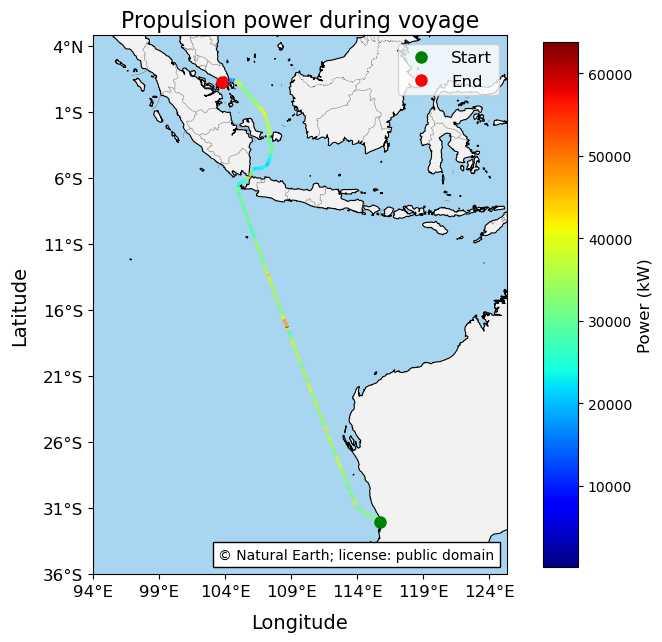

In [7]:
# Plot the vessel trajectory and color each segment by estimated propulsion power.
# Optional: if needed, filter one trajectory only
# target_id = "0_217"
# traj_df = df[df["ID"].astype(str) == target_id].copy()
traj_df = df.copy()

if traj_df.empty:
    raise ValueError("The trajectory dataframe is empty.")

traj_df["postime"] = pd.to_datetime(traj_df["postime"])
traj_df = traj_df.sort_values("postime").reset_index(drop=True)
traj_df = traj_df.dropna(subset=["lon", "lat", "Power_calc_kW"]).reset_index(drop=True)

if len(traj_df) < 2:
    raise ValueError("Not enough trajectory points to plot.")

lon = traj_df["lon"].values
lat = traj_df["lat"].values
power = traj_df["Power_calc_kW"].values

start_lon, start_lat = lon[0], lat[0]
end_lon, end_lat = lon[-1], lat[-1]

lon_min, lon_max = lon.min(), lon.max()
lat_min, lat_max = lat.min(), lat.max()

lon_pad = max((lon_max - lon_min) * 0.8, 0.3)
lat_pad = max((lat_max - lat_min) * 0.1, 0.1)

extent = [
    lon_min - lon_pad, lon_max + lon_pad,
    lat_min - lat_pad, lat_max + lat_pad
]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.PlateCarree()})

points = np.array([lon, lat]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
power_seg = (power[:-1] + power[1:]) / 2.0

norm = Normalize(vmin=np.nanmin(power), vmax=np.nanmax(power))
lc = LineCollection(
    segments,
    cmap="jet",
    norm=norm,
    linewidth=2.5,
    linestyle="-"
)
lc.set_array(power_seg)
lc.set_transform(ccrs.PlateCarree())
lc.set_zorder(4)
ax.add_collection(lc)

ax.plot(
    start_lon, start_lat,
    "go", markersize=8,
    transform=ccrs.PlateCarree(),
    zorder=6,
    label="Start"
)

ax.plot(
    end_lon, end_lat,
    "ro", markersize=8,
    transform=ccrs.PlateCarree(),
    zorder=6,
    label="End"
)

ax.set_extent(extent, crs=ccrs.PlateCarree())

SOURCE = "Natural Earth"
LICENSE = "public domain"

states_provinces = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#f2f2f2", zorder=1)
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#a8d5f0", zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8, edgecolor="black", zorder=2)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linestyle=":", linewidth=0.4, edgecolor="black", zorder=2)
ax.add_feature(states_provinces, edgecolor="gray", linewidth=0.4, zorder=2)

text = AnchoredText(
    f"© {SOURCE}; license: {LICENSE}",
    loc=4, prop={"size": 10}, frameon=True
)
ax.add_artist(text)

xticks = np.arange(np.floor(extent[0]), np.ceil(extent[1]) + 1, 5)
yticks = np.arange(np.floor(extent[2]), np.ceil(extent[3]) + 1, 5)

ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())

ax.set_xlabel("Longitude", fontsize=14, labelpad=10)
ax.set_ylabel("Latitude", fontsize=14, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())

plt.title("Propulsion power during voyage", fontsize=16)
ax.legend(loc="upper right", fontsize=12)

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.85, 0.12, 0.05, 0.75])
cbar = fig.colorbar(lc, cax=cax)
cbar.set_label("Power (kW)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.savefig("trajectory_power_distribution.png", dpi=900, bbox_inches="tight")
plt.show()

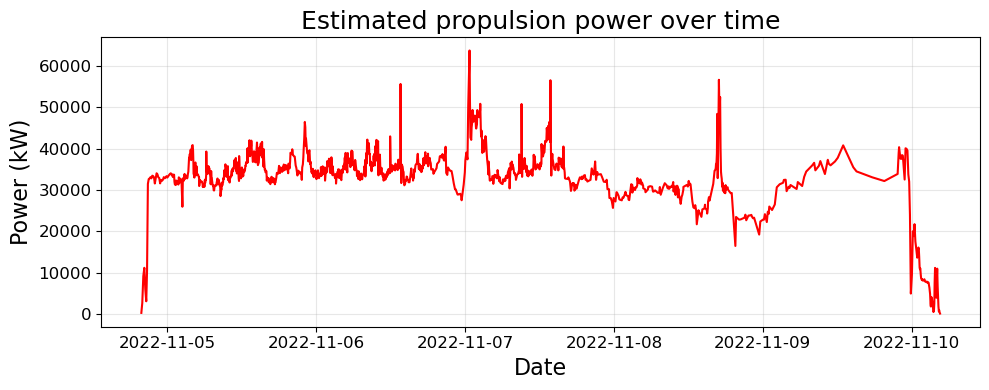

In [8]:
# Plot the estimated propulsion power time series.
font_size = 16        # adjust here
title_size = 18       # adjust here
tick_size = 12        # adjust here

df["postime"] = pd.to_datetime(df["postime"])
df_plot = df.sort_values("postime").copy()

plt.figure(figsize=(10, 4))
plt.plot(df_plot["postime"], df_plot["Power_calc_kW"], 'r', linewidth=1.5)

plt.xlabel("Date", fontsize=font_size)
plt.ylabel("Power (kW)", fontsize=font_size)
plt.title("Estimated propulsion power over time", fontsize=title_size)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.xticks(rotation=0, fontsize=tick_size)
plt.yticks(fontsize=tick_size)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("propulsion_power.svg",format = 'svg', dpi=600, bbox_inches="tight")

plt.show()

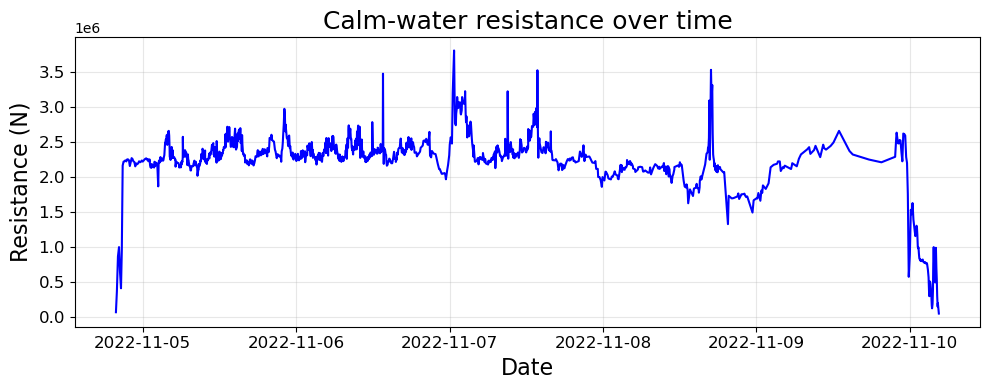

In [9]:
# Plot the calm-water resistance time series.
font_size = 16
title_size = 18
tick_size = 12

df["postime"] = pd.to_datetime(df["postime"])
df_plot = df.sort_values("postime").copy()

plt.figure(figsize=(10, 4))
plt.plot(df_plot["postime"], df_plot["R_calm_calc_N"], 'b', linewidth=1.5)

plt.xlabel("Date", fontsize=font_size)
plt.ylabel("Resistance (N)", fontsize=font_size)
plt.title("Calm-water resistance over time", fontsize=title_size)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.xticks(rotation=0, fontsize=tick_size)
plt.yticks(fontsize=tick_size)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("calm_water.svg",format = 'svg', dpi=600, bbox_inches="tight")

plt.show()

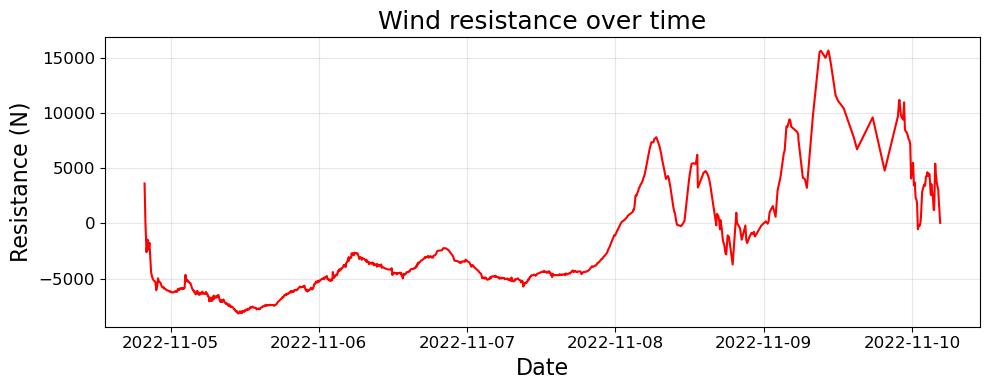

In [10]:
# Plot the wind resistance time series.
font_size = 16
title_size = 18
tick_size = 12

df["postime"] = pd.to_datetime(df["postime"])
df_plot = df.sort_values("postime").copy()

plt.figure(figsize=(10, 4))
plt.plot(df_plot["postime"], df_plot["R_wind_calc_N"], 'r', linewidth=1.5)

plt.xlabel("Date", fontsize=font_size)
plt.ylabel("Resistance (N)", fontsize=font_size)
plt.title("Wind resistance over time", fontsize=title_size)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.xticks(rotation=0, fontsize=tick_size)
plt.yticks(fontsize=tick_size)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("wind_resistance.svg",format = 'svg', dpi=600, bbox_inches="tight")

plt.show()

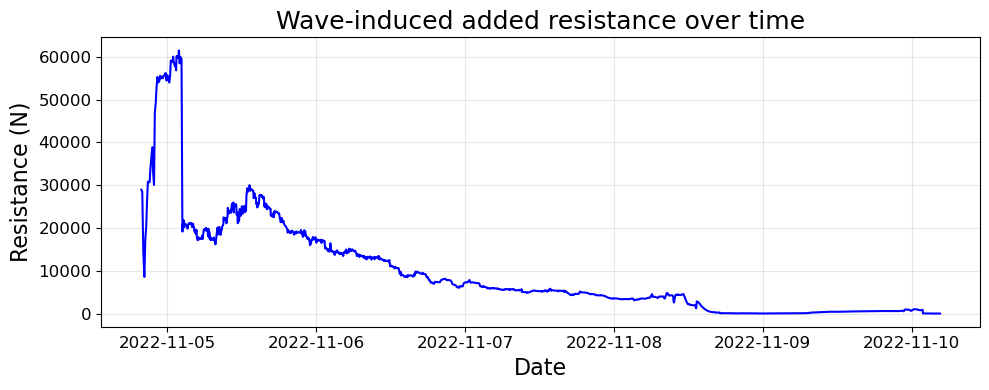

In [11]:
# Plot the wave-induced added resistance time series.
font_size = 16
title_size = 18
tick_size = 12

df["postime"] = pd.to_datetime(df["postime"])
df_plot = df.sort_values("postime").copy()

plt.figure(figsize=(10, 4))
plt.plot(df_plot["postime"], df_plot["R_wave_calc_N"], 'b', linewidth=1.5)

plt.xlabel("Date", fontsize=font_size)
plt.ylabel("Resistance (N)", fontsize=font_size)
plt.title("Wave-induced added resistance over time", fontsize=title_size)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.xticks(rotation=0, fontsize=tick_size)
plt.yticks(fontsize=tick_size)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("wave_resistance.svg",format = 'svg', dpi=600, bbox_inches="tight")

plt.show()

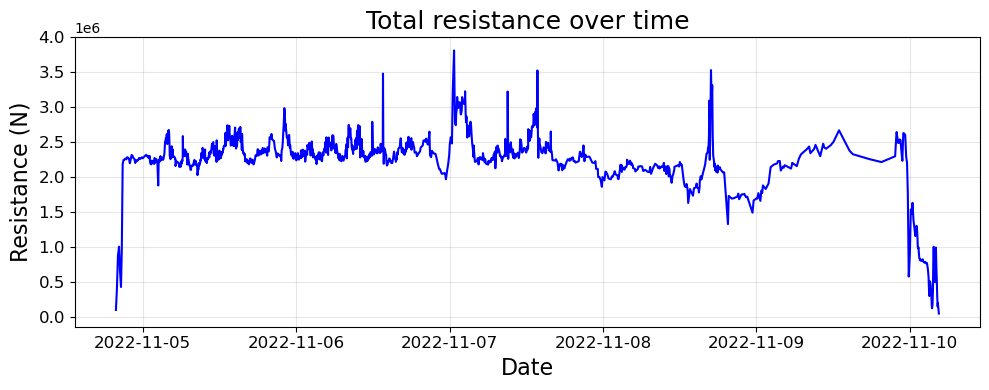

In [12]:
# Plot the total resistance time series.
font_size = 16
title_size = 18
tick_size = 12

df["postime"] = pd.to_datetime(df["postime"])
df_plot = df.sort_values("postime").copy()

plt.figure(figsize=(10, 4))
plt.plot(df_plot["postime"], df_plot["R_total_calc_N"], 'b', linewidth=1.5)

plt.xlabel("Date", fontsize=font_size)
plt.ylabel("Resistance (N)", fontsize=font_size)
plt.title("Total resistance over time", fontsize=title_size)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.xticks(rotation=0, fontsize=tick_size)
plt.yticks(fontsize=tick_size)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("total_resistance.svg",format = 'svg', dpi=600, bbox_inches="tight")

plt.show()

## 6. Plot the Vessel Track

This final map provides a simple geographic view of the vessel trajectory, including the start and end points.


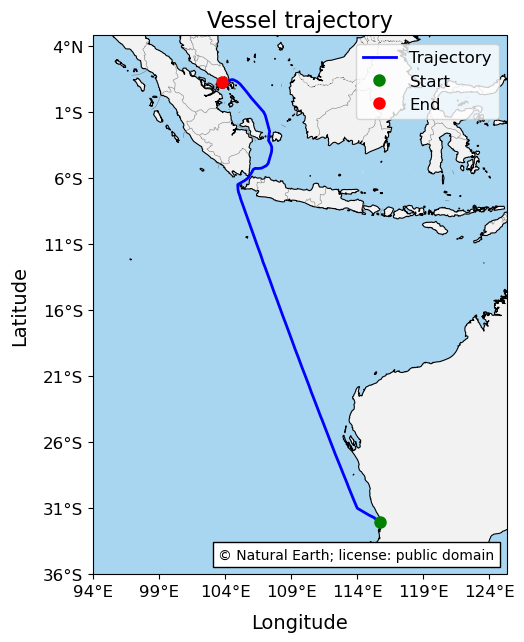

In [13]:
# Plot the vessel trajectory on a geographic map.
traj_df = df.copy()

if traj_df.empty:
    raise ValueError("The trajectory dataframe is empty.")

traj_df["postime"] = pd.to_datetime(traj_df["postime"])
traj_df = traj_df.sort_values("postime").reset_index(drop=True)
traj_df = traj_df.dropna(subset=["lon", "lat"]).reset_index(drop=True)

if len(traj_df) < 2:
    raise ValueError("Not enough trajectory points to plot.")

lon = traj_df["lon"].values
lat = traj_df["lat"].values

start_lon, start_lat = lon[0], lat[0]
end_lon, end_lat = lon[-1], lat[-1]

lon_min, lon_max = lon.min(), lon.max()
lat_min, lat_max = lat.min(), lat.max()

lon_pad = max((lon_max - lon_min) * 0.8, 0.3)
lat_pad = max((lat_max - lat_min) * 0.1, 0.1)

extent = [
    lon_min - lon_pad, lon_max + lon_pad,
    lat_min - lat_pad, lat_max + lat_pad
]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.PlateCarree()})

ax.plot(
    lon, lat,
    color="blue",
    linewidth=2.0,
    transform=ccrs.PlateCarree(),
    zorder=4,
    label="Trajectory"
)

ax.plot(
    start_lon, start_lat,
    "go", markersize=8,
    transform=ccrs.PlateCarree(),
    zorder=6,
    label="Start"
)

ax.plot(
    end_lon, end_lat,
    "ro", markersize=8,
    transform=ccrs.PlateCarree(),
    zorder=6,
    label="End"
)

ax.set_extent(extent, crs=ccrs.PlateCarree())

SOURCE = "Natural Earth"
LICENSE = "public domain"

states_provinces = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#f2f2f2", zorder=1)
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#a8d5f0", zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8, edgecolor="black", zorder=2)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linestyle=":", linewidth=0.4, edgecolor="black", zorder=2)
ax.add_feature(states_provinces, edgecolor="gray", linewidth=0.4, zorder=2)

text = AnchoredText(
    f"© {SOURCE}; license: {LICENSE}",
    loc=4, prop={"size": 10}, frameon=True
)
ax.add_artist(text)

xticks = np.arange(np.floor(extent[0]), np.ceil(extent[1]) + 1, 5)
yticks = np.arange(np.floor(extent[2]), np.ceil(extent[3]) + 1, 5)

ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())

ax.set_xlabel("Longitude", fontsize=14, labelpad=10)
ax.set_ylabel("Latitude", fontsize=14, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())

plt.title("Vessel trajectory", fontsize=16)
ax.legend(loc="upper right", fontsize=12)

plt.savefig("trajectory_plain.png", dpi=900, bbox_inches="tight")
plt.show()